# Campaign 1

The purpose of this notebook is to analyze data taken during Campaign 1 of commissioning. 

The Time Register Checkout data was taken on 09-16-2025 and 09-17-2025. 

The READ/WRITE Command Checkout was performed during a live pass on 09-19-2025. 

Last updated 09-22-2025. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
from datetime import datetime
import astropy.units as u
from pathlib import Path

from astropy.table import conf
from astropy.table import vstack
from astropy.timeseries import TimeSeries

import padre_meddea.io.file_tools as file_tools
from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.housekeeping import calibration
from padre_meddea.util import validation
from padre_meddea.util.util import is_consecutive

from padre_meddea.io.file_tools import read_file

import padre_meddea.calibration.calibration as calibration
from padre_meddea.housekeeping import calibration

In [65]:
# Function to plot housekeeping data. 
def plot_hk_converted(hk_ts, key, axlabel, title, plot=False, hist=False):  
    data=hk_ts[key]
    f=calibration.get_calibration_func(key)
    converted_data=f(data)
    print(np.shape(converted_data))

    if plot==True: 
        plt.plot(hk_ts.time.to_datetime(), converted_data, label=key)
        plt.xticks(rotation=45, ha='right') 
        plt.title(title)
        plt.xlabel('UTC Time (HH:MM:SS)')
        plt.ylabel(axlabel)
        plt.grid()
        plt.legend()
        plt.show()

    if hist==True: 
        n, bins, patches=plt.hist(converted_data, bins=30, edgecolor='black', alpha=1, label=key)
        #plt.text(f'Mean: {np.mean(converted_data):.3} \n Standard Dev: {np.std(converted_data):.3}')
        plt.title(key)
        #plt.xlabel(axlabel)
        plt.ylabel('Counts')
        plt.grid()
        plt.legend()
        plt.show()

In [2]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data/commissioning_data/raw")

In [ ]:
# Read in the data.
hk_files =['padreMDU8_250915213728.dat',
           'padreMDU8_250916215028.dat',
           'padreMDU8_250917042330.dat',
           'padreMDU8_250917060741.dat',
           'padreMDU8_250917074131.dat', 
           'padreMDU8_250917092240.dat',
           'padreMDU8_250917105030.dat',]

Confirm the start and end times for each file. Validate each file. 

In [ ]:
for this_file in hk_files: 
    hk_ts, cmd_ts = read_file(data_dir / this_file)
    print(f'Filename: {this_file} \n ')
    print(hk_ts['time'][0], hk_ts['time'][-1])

2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250915213728.dat: Found housekeeping data
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250916215028.dat: Found housekeeping data


INFO: padreMDU8_250915213728.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250915213728.dat 
 
2025-09-15 21:37:33.000 2025-09-15 21:50:03.000
INFO: padreMDU8_250916215028.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250916215028.dat: Found read data
2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250917042330.dat: Found housekeeping data
2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250917042330.dat: Found read data
2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250917060741.dat: Found housekeeping data


INFO: padreMDU8_250916215028.dat: Found read data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250916215028.dat 
 
2025-09-16 21:50:33.000 2025-09-17 04:16:53.000
INFO: padreMDU8_250917042330.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917042330.dat: Found read data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250917042330.dat 
 
2025-09-17 04:23:36.000 2025-09-17 05:53:16.000
INFO: padreMDU8_250917060741.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250917060741.dat: Found read data
2025-10-28 10:40:28 - swxsoc - INFO: padreMDU8_250917074131.dat: Found housekeeping data
2025-10-28 10:40:29 - swxsoc - INFO: padreMDU8_250917074131.dat: Found read data


INFO: padreMDU8_250917060741.dat: Found read data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250917060741.dat 
 
2025-09-17 06:07:46.000 2025-09-17 07:25:56.000
INFO: padreMDU8_250917074131.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917074131.dat: Found read data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:40:29 - swxsoc - INFO: padreMDU8_250917092240.dat: Found housekeeping data
2025-10-28 10:40:29 - swxsoc - INFO: padreMDU8_250917092240.dat: Found read data
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:75: UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header
  warnings.warn(
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 10:40:29 - swxsoc - INFO: padreMDU8_250917105030.dat: Found housekeeping data


Filename: padreMDU8_250917074131.dat 
 
2025-09-17 07:41:36.000 2025-09-17 09:08:26.000
INFO: padreMDU8_250917092240.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917092240.dat: Found read data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250917092240.dat 
 
2025-09-17 09:22:45.000 2025-09-17 10:40:55.000
INFO: padreMDU8_250917105030.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:40:30 - swxsoc - INFO: padreMDU8_250917105030.dat: Found read data


INFO: padreMDU8_250917105030.dat: Found read data [padre_meddea.housekeeping.housekeeping]
Filename: padreMDU8_250917105030.dat 
 
2025-09-17 10:50:35.000 2025-09-17 23:32:35.000


In [ ]:
for this_file in hk_files:
    print(validation.validate_packet_checksums(data_dir / this_file), validation.validate(data_dir / this_file))

[] []
[] ['UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)', 'UserWarning: File appears truncated - missing 1 bytes (or maybe garbage at end)']
[] []
[] []
[] []


c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)


[] []


c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:75: UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header
  warnings.warn(
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)
  warnings.warn(message)


[] ['UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header', 'UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)']


In [ ]:
hk_tss = []
cmd_tss = []
for this_file in hk_files: 
    hk_ts, cmd_ts = read_file(data_dir / this_file)
    print(len(hk_ts))
    print(is_consecutive(hk_ts['CCSDS_SEQUENCE_COUNT']))
    hk_tss.append(hk_ts)
    cmd_tss.append(cmd_ts)

2025-10-28 10:43:02 - swxsoc - INFO: padreMDU8_250915213728.dat: Found housekeeping data
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing 1 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 10:43:02 - swxsoc - INFO: padreMDU8_250916215028.dat: Found housekeeping data


INFO: padreMDU8_250915213728.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
76
True
INFO: padreMDU8_250916215028.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250916215028.dat: Found read data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917042330.dat: Found housekeeping data


INFO: padreMDU8_250916215028.dat: Found read data [padre_meddea.housekeeping.housekeeping]
2319
True
INFO: padreMDU8_250917042330.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917042330.dat: Found read data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917060741.dat: Found housekeeping data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917060741.dat: Found read data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917074131.dat: Found housekeeping data


INFO: padreMDU8_250917042330.dat: Found read data [padre_meddea.housekeeping.housekeeping]
539
True
INFO: padreMDU8_250917060741.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917060741.dat: Found read data [padre_meddea.housekeeping.housekeeping]
470
True
INFO: padreMDU8_250917074131.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917074131.dat: Found read data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917092240.dat: Found housekeeping data
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917092240.dat: Found read data
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:75: UserWarning: File appears truncated or with garbage bytes. Unable to enough bytes for primary header
  warnings.warn(
c:\Users\ngodbole\AppData\Local\miniforge3\envs\padre_meddea\lib\site-packages\ccsdspy\utils.py:93: UserWarning: File appears truncated-- missing -5 byte (or maybe garbage at end)
  warnings.warn(message)
2025-10-28 10:43:03 - swxsoc - INFO: padreMDU8_250917105030.dat: Found housekeeping data


INFO: padreMDU8_250917074131.dat: Found read data [padre_meddea.housekeeping.housekeeping]
522
True
INFO: padreMDU8_250917092240.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250917092240.dat: Found read data [padre_meddea.housekeeping.housekeeping]
470
True
INFO: padreMDU8_250917105030.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]


2025-10-28 10:43:04 - swxsoc - INFO: padreMDU8_250917105030.dat: Found read data


INFO: padreMDU8_250917105030.dat: Found read data [padre_meddea.housekeeping.housekeeping]
4573
True


Time Register Checkout. Open the command list and examine the READs from the MET Core registers. 

In [11]:
cmd_ts

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,str25
2025-09-17 11:24:05.394,811423450,7874665,1032,17,0,time_core_status
2025-09-17 11:25:05.463,811423510,9256490,1034,12,1,time_intvector
2025-09-17 11:26:05.006,811423570,127251,1040,11883,2,time_last_offset0_least
2025-09-17 11:27:05.116,811423630,2318319,1042,305,3,time_last_offset0_most
2025-09-17 11:28:05.180,811423690,3590238,1044,11882,4,time_pps_count0_least
2025-09-17 11:29:05.284,811423750,5684293,1046,305,5,time_pps_count0_most
2025-09-17 11:30:05.352,811423810,7040080,1072,11880,6,time_last1sec_count_least
2025-09-17 11:31:05.047,811423870,940514,1074,305,7,time_last1sec_count_most
2025-09-17 12:24:05.031,811427050,612053,1032,17,8,time_core_status


In [14]:
# Filter out None values before stacking
# Tell vstack how to handle metadata conflicts
valid_cmd_tss = [ts for ts in cmd_tss if ts is not None]
tot_cmd_ts = vstack(valid_cmd_tss, metadata_conflicts='silent')

In [15]:
tot_cmd_ts

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,str25
2025-09-16 21:59:55.049,811375200,970503,1032,17,0,time_core_status
2025-09-16 22:00:55.207,811375260,4142676,1034,12,1,time_intvector
2025-09-16 22:01:55.266,811375320,5314803,1040,11895,2,time_last_offset0_least
2025-09-16 22:02:55.353,811375380,7068952,1042,305,3,time_last_offset0_most
2025-09-16 22:03:55.408,811375440,8169839,1044,11894,4,time_pps_count0_least
2025-09-16 22:04:55.065,811375500,1301954,1046,305,5,time_pps_count0_most
2025-09-16 22:05:55.088,811375560,1756297,1072,11858,6,time_last1sec_count_least
2025-09-16 22:06:55.226,811375620,4511123,1074,305,7,time_last1sec_count_most
2025-09-16 22:07:55.294,811375680,5883594,34,1,8,asic0_icomp


In [17]:
tot_hk_ts = vstack([hk_tss[i] for i in range(len(hk_tss))], metadata_conflicts='silent')

In [18]:
tot_hk_ts[0]['time'], tot_hk_ts[-1]['time'], 

(<Time object: scale='utc' format='iso' value=2025-09-15 21:37:33.000>,
 <Time object: scale='utc' format='iso' value=2025-09-17 23:32:35.000>)

Investigate the error_summary. 

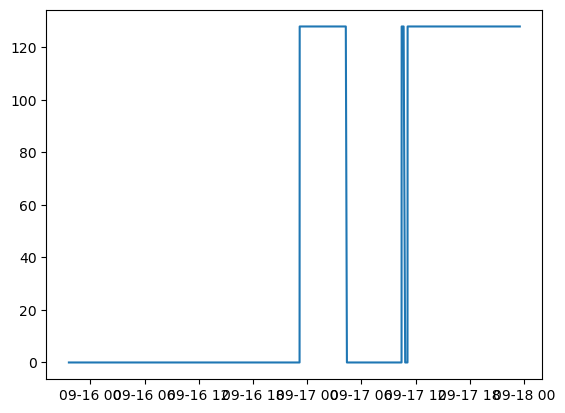

In [19]:
plt.plot(tot_hk_ts['time'].to_datetime(), tot_hk_ts['error_summary'])

Time Register Checkout. Examine the now combined command table.

Confirmed with Ace: The first and last commands in this timeseries correspond to the GMT timesamps when the corresponding register READ commands were sent to the spacecraft. 

In [25]:
tot_cmd_ts['value'][tot_cmd_ts['name']=='time_intvector']

12
12
12
12
12
12
12
12
12
12
12


Register "time_intvector" reads as expected throughout this interval. 

In [24]:
tot_cmd_ts['value'][tot_cmd_ts['name']=='time_core_status']

17
17
17
17
17
17
17
17
17
17
17


Register "time_core_status" reads as expected throughout this interval. 

In [87]:
time_last_offset0_most = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_last_offset0_most']
time_last_offset0_least = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_last_offset0_least']
time_last_offset = (time_last_offset0_most * 65536.) + time_last_offset0_least

print(f'Average Value: {np.mean(time_last_offset)} \n Standard Deviation: {np.std(time_last_offset)} \n Drift (should be < {50/1000000}): {(np.mean(time_last_offset) - 20000000)/20000000}')

Average Value: 20000285.56521739 
 Standard Deviation: 29.848641491126273 
 Drift (should be < 5e-05): 1.4278260869532823e-05


In [88]:
time_pps_count0_most = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_pps_count0_most']
time_pps_count0_least = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_pps_count0_least']
time_pps_count = (time_pps_count0_most * 65536.) + time_pps_count0_least

print(f'Average Value: {np.mean(time_pps_count)} \n Standard Deviation: {np.std(time_pps_count)} \n Drift (should be < {50/1000000}): {(np.mean(time_pps_count) - 20000000)/20000000}')

Average Value: 20000285.086956523 
 Standard Deviation: 28.96011206361675 
 Drift (should be < 5e-05): 1.4254347826167941e-05


In [89]:
last_1_sec_count_most = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_last1sec_count_most']
last_1_sec_count_least = tot_cmd_ts['value'][tot_cmd_ts['name']=='time_last1sec_count_least']
last_1sec_count = (last_1_sec_count_most * 65536.) + last_1_sec_count_least

print(f'Average Value: {np.mean(last_1sec_count)} \n Standard Deviation: {np.std(last_1sec_count)} \n Drift (should be < {50/1000000}): {(np.mean(last_1sec_count) - 20000000)/20000000}')

Average Value: 20000283.13043478 
 Standard Deviation: 24.245670788511447 
 Drift (should be < 5e-05): 1.4156521739065647e-05


Check the READ values for the ASIC threshold registers. Because the values for the asic threshold registers were not re-uploaded ot the OBC after launch, the READ values for each configuration will equal the values of the Default configuration. Ace is planning to upload these values in the coming weeks, after which we will repeat this READ checkout to verify that the threshold registers are set correctly for each configuration mode. 

In [40]:
# Not all of the ASIC threshold registers were read. 
# Since the number of commands in the scheduler are limited, not all of the intended READ commands were performed. 
# Check to see which commands went through. 
existing_names = set(tot_cmd_ts['name'])

for this_asic in range(4):
    print(f"\nASIC {this_asic} Thresholds")
    for this_threshold in range(1, 17): 
        column_name = f'asic{this_asic}_threshold{this_threshold}'
        if column_name in existing_names:
            result = tot_cmd_ts[tot_cmd_ts['name']==column_name]
            print(f"{column_name}:")
            print(result)
            print()


ASIC 0 Thresholds
asic0_threshold1:
          time           pkttimes pktclock ... value seqcount       name      
----------------------- --------- -------- ... ----- -------- ----------------
2025-09-16 23:07:55.233 811379280  4669698 ... 15677       68 asic0_threshold1
2025-09-17 00:20:55.249 811383660  4980397 ... 15677      140 asic0_threshold1
2025-09-17 01:33:55.141 811388040  2816794 ... 15677      212 asic0_threshold1

asic0_threshold2:
          time           pkttimes pktclock ... value seqcount       name      
----------------------- --------- -------- ... ----- -------- ----------------
2025-09-16 23:11:55.083 811379520  1660657 ...  7487       72 asic0_threshold2
2025-09-17 00:24:55.033 811383900   664161 ...  7487      144 asic0_threshold2
2025-09-17 01:37:55.122 811388280  2433906 ...  7487      216 asic0_threshold2

asic0_threshold3:
          time           pkttimes pktclock ... value seqcount       name      
----------------------- --------- -------- ... ----- ---

Ignore the following cell. I wanted to investigate the good_cmd_cnt to see whether all of the READ commands went through, but this was before we knew that the issue was with the scheduler. 

In [ ]:
start_time = Time('2025-09-16 23:59:00')
end_time = Time('2025-09-17 00:01:00')

# Filter the TimeSeries
filtered_data = tot_hk_ts[(tot_hk_ts.time >= start_time) & (tot_hk_ts.time <= end_time)]

In [92]:
filtered_data['time'], filtered_data['good_cmd_cnt']

(<Time object: scale='utc' format='iso' value=['2025-09-16 23:59:03.000' '2025-09-16 23:59:13.000'
  '2025-09-16 23:59:23.000' '2025-09-16 23:59:33.000'
  '2025-09-16 23:59:43.000' '2025-09-16 23:59:53.000'
  '2025-09-17 00:00:03.000' '2025-09-17 00:00:13.000'
  '2025-09-17 00:00:23.000' '2025-09-17 00:00:33.000'
  '2025-09-17 00:00:43.000' '2025-09-17 00:00:53.000']>,
 <Column name='good_cmd_cnt' dtype='uint16' length=12>
 127
 127
 127
 127
 127
 127
 128
 128
 128
 128
 128
 128)

In [ ]:
start_time = Time('2025-09-17 01:31:00')
end_time = Time('2025-09-17 01:35:00')

# Filter the TimeSeries
filtered_data = tot_hk_ts[(tot_hk_ts.time >= start_time) & (tot_hk_ts.time <= end_time)]

In [94]:
filtered_data['time'], filtered_data['good_cmd_cnt']

(<Time object: scale='utc' format='iso' value=['2025-09-17 01:31:03.000' '2025-09-17 01:31:13.000'
  '2025-09-17 01:31:23.000' '2025-09-17 01:31:33.000'
  '2025-09-17 01:31:43.000' '2025-09-17 01:31:53.000'
  '2025-09-17 01:32:03.000' '2025-09-17 01:32:13.000'
  '2025-09-17 01:32:23.000' '2025-09-17 01:32:33.000'
  '2025-09-17 01:32:43.000' '2025-09-17 01:32:53.000'
  '2025-09-17 01:33:03.000' '2025-09-17 01:33:13.000'
  '2025-09-17 01:33:23.000' '2025-09-17 01:33:33.000'
  '2025-09-17 01:33:43.000' '2025-09-17 01:33:53.000'
  '2025-09-17 01:34:03.000' '2025-09-17 01:34:13.000'
  '2025-09-17 01:34:23.000' '2025-09-17 01:34:33.000'
  '2025-09-17 01:34:43.000' '2025-09-17 01:34:53.000']>,
 <Column name='good_cmd_cnt' dtype='uint16' length=24>
 218
 218
 218
 218
 218
 218
 219
 219
 219
 219
 219
 219
 219
 219
 219
 219
 219
 219
 220
 220
 220
 220
 220
 220)

Check the register READs from READ/WRITE command checkout on 09/19/25. 

In [55]:
hk_file = 'padreMDU8_250919172602.dat'
#hk_file = 'padre_meddea_l1_housekeeping_20250919T000000_v1.0.0.fits'

In [56]:
print(validation.validate_packet_checksums(data_dir / hk_file), validation.validate(data_dir / hk_file))

[] []


In [57]:
hk_ts, cmd_ts = read_file(data_dir / hk_file)

2025-10-28 11:17:43 - swxsoc - INFO: padreMDU8_250919172602.dat: Found housekeeping data
2025-10-28 11:17:43 - swxsoc - INFO: padreMDU8_250919172602.dat: Found read data


INFO: padreMDU8_250919172602.dat: Found housekeeping data [padre_meddea.housekeeping.housekeeping]
INFO: padreMDU8_250919172602.dat: Found read data [padre_meddea.housekeeping.housekeeping]


In [58]:
print(is_consecutive(hk_ts['CCSDS_SEQUENCE_COUNT']))

True


In [59]:
hk_ts['time']

<Time object: scale='utc' format='iso' value=['2025-09-19 17:26:07.000' '2025-09-19 17:26:17.000'
 '2025-09-19 17:26:27.000' '2025-09-19 17:26:37.000'
 '2025-09-19 17:26:47.000' '2025-09-19 17:26:57.000'
 '2025-09-19 17:27:07.000' '2025-09-19 17:27:17.000'
 '2025-09-19 17:27:27.000' '2025-09-19 17:27:37.000'
 '2025-09-19 17:27:47.000' '2025-09-19 17:27:57.000'
 '2025-09-19 17:28:07.000' '2025-09-19 17:28:17.000'
 '2025-09-19 17:28:27.000' '2025-09-19 17:28:37.000'
 '2025-09-19 17:28:47.000' '2025-09-19 17:28:57.000'
 '2025-09-19 17:29:07.000' '2025-09-19 17:29:17.000'
 '2025-09-19 17:29:27.000' '2025-09-19 17:29:37.000'
 '2025-09-19 17:29:47.000' '2025-09-19 17:29:57.000'
 '2025-09-19 17:30:07.000' '2025-09-19 17:30:17.000'
 '2025-09-19 17:30:27.000' '2025-09-19 17:30:37.000'
 '2025-09-19 17:30:47.000' '2025-09-19 17:30:57.000'
 '2025-09-19 17:31:07.000' '2025-09-19 17:31:17.000'
 '2025-09-19 17:31:27.000' '2025-09-19 17:31:37.000'
 '2025-09-19 17:31:47.000' '2025-09-19 17:31:57.000'
 

In [60]:
hk_converted = calibration.calibrate_hk_ts(hk_ts)

How much time does this file cover? 

In [61]:
hk_converted['time'][0], hk_converted['time'][-1]

(<Time object: scale='utc' format='iso' value=2025-09-19 17:26:07.000>,
 <Time object: scale='utc' format='iso' value=2025-09-19 17:38:27.000>)

In [63]:
(Time(hk_converted['time'][-1]) - Time(hk_converted['time'][0])).to_value('sec')*u.s.to(u.min)

np.float64(12.333333333333396)

(75,)


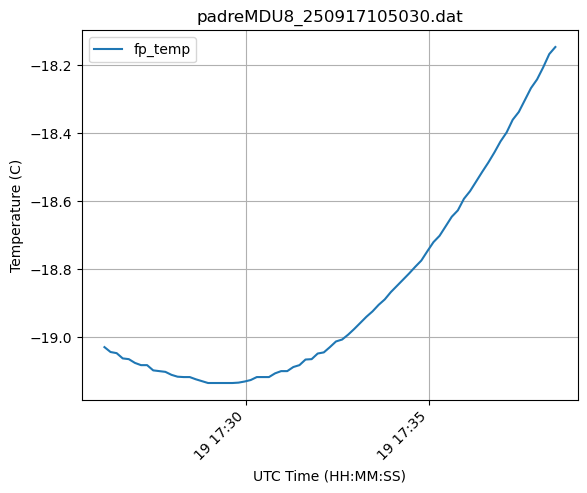

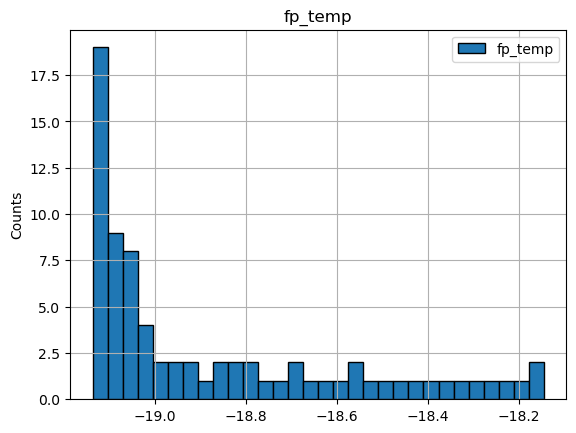

(75,)


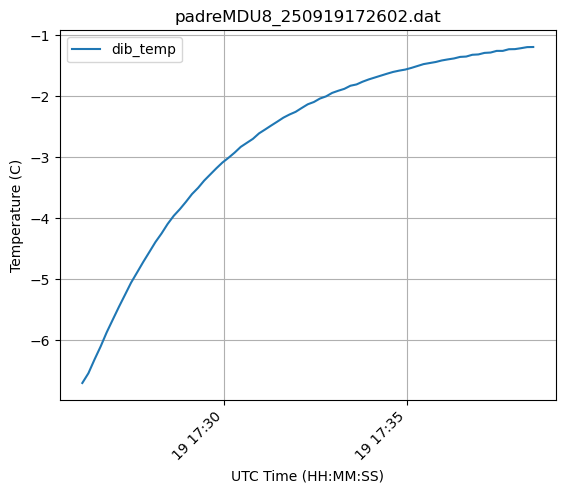

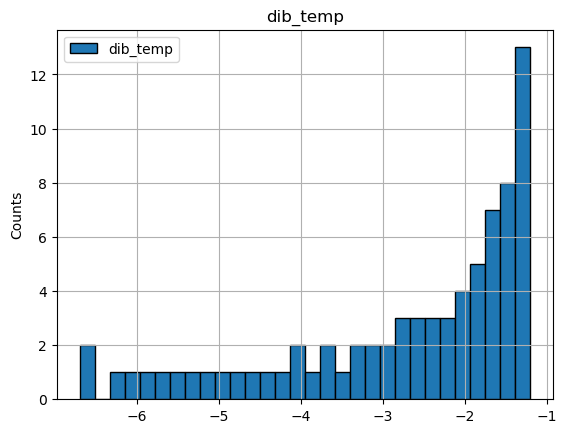

(75,)


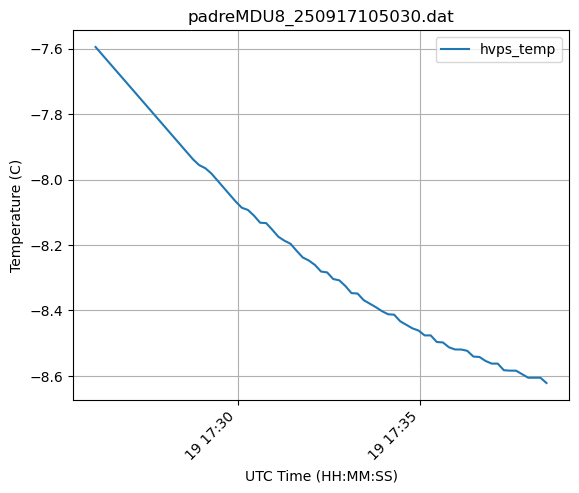

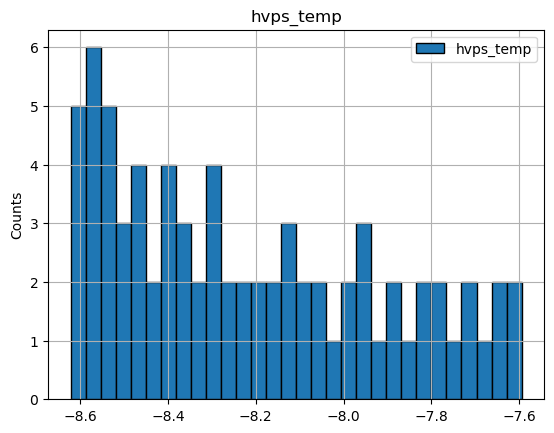

fp_temp ranged from -19.135781127402755 deg_C to -18.145646365104174 deg_C .
fp_temp mean: -18.871247480535388 deg_C fp_temp standard deviation 0.29534761918815516 deg_C
dib_temp ranged from -6.704218423923244 deg_C to -1.1979227495754543 deg_C .
hvps_temp ranged from -8.62158363652856 deg_C to -7.59477256792927 deg_C .


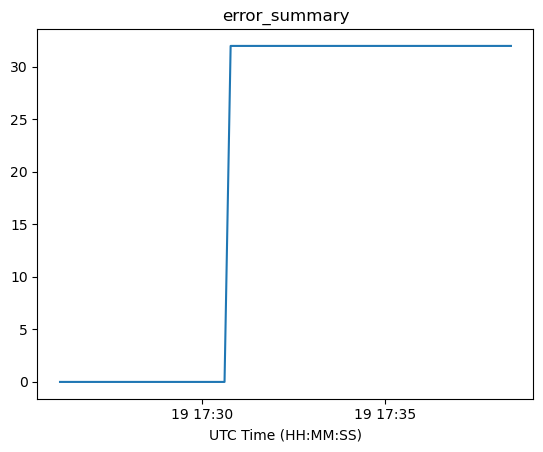

error_summary
-------------
            0
            0
            0
            0
            0
            0
            0
            0
            0
            0
          ...
           32
           32
           32
           32
           32
           32
           32
           32
           32
           32
Length = 75 rows


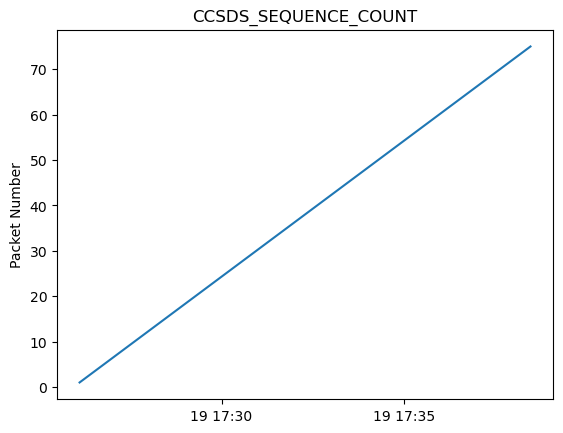

In [66]:
# Plot the converted temperature data. 

plot_hk_converted(hk_ts, 'fp_temp', 'Temperature (C)', str(this_file), plot=True, hist=True) #fp_temp consistently stays within +/- 1C.
plot_hk_converted(hk_ts, 'dib_temp', 'Temperature (C)', str(hk_file), plot=True, hist=True)
plot_hk_converted(hk_ts, 'hvps_temp', 'Temperature (C)', str(this_file), plot=True, hist=True) #hvps was not connected for these tests. 

print('fp_temp ranged from', str(np.amin(hk_converted['fp_temp'])), 'to', str(np.amax(hk_converted['fp_temp'])), '.')
print('fp_temp mean:', str(np.mean(hk_converted['fp_temp'])), 'fp_temp standard deviation', str(np.std(hk_converted['fp_temp'])))

print('dib_temp ranged from', str(np.amin(hk_converted['dib_temp'])), 'to', str(np.amax(hk_converted['dib_temp'])), '.')
print('hvps_temp ranged from', str(np.amin(hk_converted['hvps_temp'])), 'to', str(np.amax(hk_converted['hvps_temp'])), '.')

plt.plot(hk_ts.time.to_datetime(), hk_ts['error_summary']) 
plt.title('error_summary')
plt.xlabel('UTC Time (HH:MM:SS)')
plt.show()

print(hk_ts['error_summary'])

plt.plot(hk_ts.time.to_datetime(), hk_ts['CCSDS_SEQUENCE_COUNT'])
#plt.plot(hk_ts.time.to_datetime(), hk_ts['seqcount'])
plt.title('CCSDS_SEQUENCE_COUNT')
plt.ylabel('Packet Number') 
plt.show()

error_summary = 32 corresponds to a Caliste Read/Write error. 

In [105]:
cmd_ts

time,pkttimes,pktclock,address,value,seqcount,name
Time,uint32,uint32,uint16,uint16,uint16,str28
2025-09-19 17:29:37.605,811618182,12101770,1280,40605,0,commit_hash_least
2025-09-19 17:29:40.108,811618185,2161410,1282,24802,1,commit_hash_most
2025-09-19 17:29:43.361,811618188,7221451,4,10000,2,pulser_width
2025-09-19 17:29:46.964,811618191,19281683,1032,17,3,time_core_status
2025-09-19 17:29:49.417,811618194,8341415,1034,12,4,time_intvector
2025-09-19 17:29:51.770,811618196,15401499,1040,11830,5,time_last_offset0_least
2025-09-19 17:29:52.673,811618197,13461469,1040,11831,6,time_last_offset0_least
2025-09-19 17:29:55.176,811618200,3521258,1042,305,7,time_last_offset0_most
2025-09-19 17:29:57.629,811618202,12581372,1044,11829,8,time_pps_count0_least


In [106]:
cmd_ts.pprint(max_lines=-1, max_width=-1)

          time           pkttimes pktclock address value seqcount             name            
----------------------- --------- -------- ------- ----- -------- ----------------------------
2025-09-19 17:29:37.605 811618182 12101770    1280 40605        0            commit_hash_least
2025-09-19 17:29:40.108 811618185  2161410    1282 24802        1             commit_hash_most
2025-09-19 17:29:43.361 811618188  7221451       4 10000        2                 pulser_width
2025-09-19 17:29:46.964 811618191 19281683    1032    17        3             time_core_status
2025-09-19 17:29:49.417 811618194  8341415    1034    12        4               time_intvector
2025-09-19 17:29:51.770 811618196 15401499    1040 11830        5      time_last_offset0_least
2025-09-19 17:29:52.673 811618197 13461469    1040 11831        6      time_last_offset0_least
2025-09-19 17:29:55.176 811618200  3521258    1042   305        7       time_last_offset0_most
2025-09-19 17:29:57.629 811618202 12581372    1044

caliste_register_error and caliste_register_error_count are fairly new registers... 
Spoke with Kyle, he thinks that these high values may indicate a bug. 

caliste_register_error: Tells which ASIC and which register had the error. If multiple ASICs/registers had errors, this will reflect the value of the last one. 
"52" Corresponds to ASIC3, Caliste seltest register. 

caliste_register_error_count: 

The read/write did work though, why are we getting errors? 
Why are there so many errors? 508 is a large number. 

Try: read 22, 24 before writing to an ASIC register. read 22, 24, after the write command. 

In [107]:
time_last_offset0_most = cmd_ts['value'][cmd_ts['name']=='time_last_offset0_most']
time_last_offset0_least = cmd_ts['value'][cmd_ts['name']=='time_last_offset0_least']
time_last_offset = (time_last_offset0_most * 65536.) + time_last_offset0_least

print(f'time_last_offset: \n Average Value: {np.mean(time_last_offset)} \n Standard Deviation: {np.std(time_last_offset)} \n Drift (should be < {50/1000000}): {(np.mean(time_last_offset) - 20000000)/20000000}')

time_pps_count0_most = cmd_ts['value'][cmd_ts['name']=='time_pps_count0_most']
time_pps_count0_least = cmd_ts['value'][cmd_ts['name']=='time_pps_count0_least']
time_pps_count = (time_pps_count0_most * 65536.) + time_pps_count0_least

print(f'time_pps_count: \n Average Value: {np.mean(time_pps_count)} \n Standard Deviation: {np.std(time_pps_count)} \n Drift (should be < {50/1000000}): {(np.mean(time_pps_count) - 20000000)/20000000}')

last_1_sec_count_most = cmd_ts['value'][cmd_ts['name']=='time_last1sec_count_most']
last_1_sec_count_least = cmd_ts['value'][cmd_ts['name']=='time_last1sec_count_least']
last_1sec_count = (last_1_sec_count_most * 65536.) + last_1_sec_count_least

print(f'time_last1sec_count: \n Average Value: {np.mean(last_1sec_count)} \n Standard Deviation: {np.std(last_1sec_count)} \n Drift (should be < {50/1000000}): {(np.mean(last_1sec_count) - 20000000)/20000000}')

time_last_offset: 
 Average Value: 20000310.5 
 Standard Deviation: 0.5 
 Drift (should be < 5e-05): 1.5525e-05
time_pps_count: 
 Average Value: 20000309.0 
 Standard Deviation: 0.0 
 Drift (should be < 5e-05): 1.545e-05
time_last1sec_count: 
 Average Value: 20000309.0 
 Standard Deviation: 0.0 
 Drift (should be < 5e-05): 1.545e-05


In [108]:
hk_ts.pprint(max_lines=-1, max_width=-1)

          time          CCSDS_VERSION_NUMBER CCSDS_PACKET_TYPE CCSDS_SECONDARY_FLAG CCSDS_APID CCSDS_SEQUENCE_FLAG CCSDS_SEQUENCE_COUNT CCSDS_PACKET_LENGTH  pkttimes fp_temp dib_temp hvps_temp hvps_vsense hvps_csense csense_15v csense_33vd csense_33va hit_rate good_cmd_cnt error_cnt heater_pwm_duty_cycle decimation_rate error_summary checksum
----------------------- -------------------- ----------------- -------------------- ---------- ------------------- -------------------- ------------------- --------- ------- -------- --------- ----------- ----------- ---------- ----------- ----------- -------- ------------ --------- --------------------- --------------- ------------- --------
2025-09-19 17:26:07.000                    0                 0                    0        163                   3                    1                  33 811617972   34000    55092     41056        1103        4240      28170       36676       37053        0            7         0                     0     

error_summary went from 0 to 32 @ 2025-09-19 17:30:47.000 -- indicates a Caliste READ/WRITE error. 